# Career Uncertainty Drivers – ASPIRES3 Analysis

## Table of Contents
1. [Objective](#objective)
2. [Import Libraries and Load Data](#import-libraries-and-load-data)
3. [Data Cleaning](#data-cleaning)
   - 3.1 Replace Missing Codes (998, 999) with NaN
   - 3.2 Drop Columns with >50% Missing
4. [Create Target Variable (CONCERN_R)](#create-target-variable-concern_r)
5. [Associate All Columns with Target](#associate-all-columns-with-target)
6. [Select Top 20 Correlates](#select-top-20-correlates)
7. [Initial Regression and VIF](#initial-regression-and-vif)
8. [Model Refinement](#model-refinement)
   - 8.1 Create Mental Health Composite
   - 8.2 Backward Elimination
   - 8.3 Create Job Perception Composite
9. [Final Model](#final-model)
   - 9.1 Regression Results
   - 9.2 VIF Check
   - 9.3 Cross‑Validation
10. [Visualization: Coefficient Plot](#visualization-coefficient-plot)
11. [Summary and Conclusions](#summary-and-conclusions)

---

## 1. Objective
To analyze the ASPIRES3 dataset and determine the primary drivers of career‑related concern among young adults (ages 21‑22). Through rigorous statistical modeling, this project identifies malleable factors—such as confidence in future job, sense of belonging, and mental health—that can be targeted by edtech platforms to alleviate student anxiety and improve career outcomes.

## 2. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm

df_full = pd.read_table('/kaggle/input/datasets/robinhuang87/aspire-survey/aspires3_survey.tab')
df_full.head()

,DOBSCREEN,DOBSCREEN2,RES,GENDER,AGE,ETH,ETH_BBRI,ETH_CAR,ETH_AFR,ETH_OTHB,...,stemdeg_07,stemdeg_08,stemdeg_09,stemdeg_10,stemdeg_11,studying,curr_deg_level,comp_deg_level,level,type
0,999,4,1,2,999,7,999,999,999,999,...,0,1,0,0,0,997,997,999,996,999
1,1,999,1,1,999,1,0,1,0,0,...,0,0,0,0,1,1,1,999,1,997
2,1,999,1,2,999,3,999,999,999,999,...,996,996,996,996,996,1,1,999,1,997
3,1,999,1,1,999,4,999,999,999,999,...,0,0,0,1,0,1,1,997,1,997
4,999,4,1,1,999,3,999,999,999,999,...,0,0,0,0,1,1,2,1,3,1


## 3. Data Cleaning

### 3.1 Replace Missing Codes (998, 999) with NaN

In [2]:
df_full.replace([998, 999], np.nan, inplace=True)

In [3]:

missing_percent = df_full.isna().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)
print(missing_percent.head(20))

AGE                100.000000
ACA_QUAL_07_SCH     99.502292
ACA_QUAL_10_SCH     99.502292
ACA_QUAL_09_SCH     99.502292
ACA_QUAL_08_SCH     99.502292
ACA_QUAL_05_SCH     99.502292
ACA_QUAL_01_SCH     99.502292
ACA_QUAL_04_SCH     99.502292
ACA_QUAL_03_SCH     99.502292
ACA_QUAL_02_SCH     99.502292
FUTJOB_TRAIN        99.502292
RIGHT_DEC_SCH       99.502292
ACA_QUAL_06_SCH     99.502292
ACA_QUAL_03_OTH     99.187950
ACA_QUAL_04_OTH     99.187950
ACA_QUAL_02_OTH     99.187950
ACA_QUAL_05_OTH     99.187950
ACA_QUAL_09_OTH     99.187950
ACA_QUAL_06_OTH     99.187950
RIGHT_DEC_EDU       99.187950
dtype: float64


### 3.2 Drop Columns with >50% Missing

In [4]:
threshold = 50
cols_to_drop = missing_percent[missing_percent > threshold].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with >{threshold}% missing.")

df_filtered = df_full.drop(columns=cols_to_drop)

Dropping 404 columns with >50% missing.


## 4. Create Target Variable (CONCERN_R)

In [5]:
if 'CONCERN' in df_filtered.columns:
    df_filtered['CONCERN_R'] = 6 - df_filtered['CONCERN']
else:
    print("Warning: CONCERN column not found!")

## 5. Associate All Columns with Target

In [6]:
#Compute association using pearson_r for numerical or ANOVA for categorical
def get_association(df, target, col):
    data = df[[col, target]].dropna()
    if len(data) < 10:
        return ('too_few', np.nan, np.nan, len(data))
    
    x = data[col]
    y = data[target]
    
    
    if pd.api.types.is_numeric_dtype(x):
        r, p = stats.pearsonr(x, y)
        return ('pearson_r', r, p, len(data))
    else:
        groups = [y[x == cat] for cat in x.unique()]
        if any(len(g) < 2 for g in groups):
            return ('cat_too_small', np.nan, np.nan, len(data))
        f_stat, p_val = stats.f_oneway(*groups)
        ss_between = sum(len(g) * (g.mean() - y.mean())**2 for g in groups)
        ss_total = sum((y - y.mean())**2)
        eta_sq = ss_between / ss_total if ss_total != 0 else 0
        return ('eta_sq', eta_sq, p_val, len(data))


In [7]:
results = []
for col in df_filtered.columns:
    if col in ['CONCERN_R', 'CONCERN']:
        continue
    measure, value, p, n = get_association(df_filtered, 'CONCERN_R', col)
    results.append({
        'column': col,
        'measure': measure,
        'value': value,
        'p_value': p,
        'n': n
    })

results_df = pd.DataFrame(results)
results_df['abs_value'] = results_df['value'].abs()
results_df = results_df.sort_values('abs_value', ascending=False).drop('abs_value', axis=1)

print(results_df.head(20))

/tmp/ipykernel_55/2119592144.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(x, y)
/tmp/ipykernel_55/2119592144.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(x, y)
/tmp/ipykernel_55/2119592144.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(x, y)
/tmp/ipykernel_55/2119592144.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(x, y)


             column    measure     value        p_value     n
190       COVID_ASP  pearson_r -0.391318  8.886652e-272  7467
331         LIFESAT  pearson_r -0.336065  3.536348e-197  7491
148         JOBPER1  pearson_r  0.284129   1.280322e-80  4298
191     CONF_FUTJOB  pearson_r  0.283092  7.663460e-138  7479
193     CAR_SAT_EMP  pearson_r  0.274958   2.452683e-79  4527
358            PHQ2  pearson_r  0.272423  2.901279e-127  7471
154         JOBPER7  pearson_r -0.272062   9.172062e-74  4295
149         JOBPER2  pearson_r  0.266073   1.402004e-70  4299
356            GAD2  pearson_r  0.261324  7.989392e-117  7466
357            PHQ1  pearson_r  0.260215  8.130500e-116  7466
355            GAD1  pearson_r  0.256865  5.573944e-113  7478
187  RIGHT_DEC_WORK  pearson_r  0.249836   3.311394e-62  4301
152         JOBPER5  pearson_r  0.243709   3.890360e-59  4297
151         JOBPER4  pearson_r  0.240623   1.157237e-57  4298
198   NO_CAR_RES_05  pearson_r -0.234491   1.580514e-61  4846
173     

/tmp/ipykernel_55/2119592144.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(x, y)
/tmp/ipykernel_55/2119592144.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(x, y)


## 6. Select Top 20 Correlates

In [8]:
top20_cols = [
    'COVID_ASP',
    'LIFESAT',
    'JOBPER1',
    'CONF_FUTJOB',
    'CAR_SAT_EMP',
    'PHQ2',
    'JOBPER7' ,
    'JOBPER2',
    'GAD2',
    'PHQ1',
    'GAD1',
    'RIGHT_DEC_WORK',
    'JOBPER5',
    'JOBPER4',
    'NO_CAR_RES_05',
    'PREV_PG_02',
    'BROAD',
    'NO_CAR_RES_01',
    'BELONG',
    'NO_CAR_RES_03'
             
]

## 7. Initial Regression and VIF

In [9]:
demographic_cols = ['GENDER', 'PAR1UNI','PAR2UNI', 'REGION', 'ETH']

cols_to_keep = top20_cols + demographic_cols + ['CONCERN_R']

existing_cols = [col for col in cols_to_keep if col in df_filtered.columns]
print(f"Keeping {len(existing_cols)} columns: {existing_cols}")

Keeping 26 columns: ['COVID_ASP', 'LIFESAT', 'JOBPER1', 'CONF_FUTJOB', 'CAR_SAT_EMP', 'PHQ2', 'JOBPER7', 'JOBPER2', 'GAD2', 'PHQ1', 'GAD1', 'RIGHT_DEC_WORK', 'JOBPER5', 'JOBPER4', 'NO_CAR_RES_05', 'PREV_PG_02', 'BROAD', 'NO_CAR_RES_01', 'BELONG', 'NO_CAR_RES_03', 'GENDER', 'PAR1UNI', 'PAR2UNI', 'REGION', 'ETH', 'CONCERN_R']


In [10]:
df_top20 = df_filtered[existing_cols].copy()
df_top20['parent_uni'] = ((df_top20['PAR1UNI'] == 1) | (df_top20['PAR2UNI'] == 1)).astype(float)
df_top20.drop(columns=['PAR1UNI', 'PAR2UNI'], inplace=True, errors='ignore')

In [11]:
df_top20.head()

,COVID_ASP,LIFESAT,JOBPER1,CONF_FUTJOB,CAR_SAT_EMP,PHQ2,JOBPER7,JOBPER2,GAD2,PHQ1,...,PREV_PG_02,BROAD,NO_CAR_RES_01,BELONG,NO_CAR_RES_03,GENDER,REGION,ETH,CONCERN_R,parent_uni
0,3.0,8.0,NaN,2.0,NaN,1.0,NaN,NaN,1.0,1.0,...,0,3.0,NaN,3.0,NaN,2.0,6.0,7.0,3.0,0.0
1,3.0,6.0,NaN,3.0,NaN,1.0,NaN,NaN,1.0,2.0,...,1,3.0,NaN,5.0,NaN,1.0,8.0,1.0,2.0,0.0
2,3.0,8.0,NaN,2.0,NaN,1.0,NaN,NaN,2.0,2.0,...,0,2.0,NaN,3.0,NaN,2.0,8.0,3.0,2.0,0.0
3,2.0,4.0,NaN,2.0,NaN,2.0,NaN,NaN,3.0,3.0,...,0,3.0,NaN,3.0,NaN,1.0,4.0,4.0,4.0,0.0
4,2.0,7.0,NaN,2.0,NaN,3.0,NaN,NaN,4.0,2.0,...,1,3.0,1.0,3.0,1.0,1.0,2.0,3.0,5.0,1.0


In [12]:
for col in top20_cols:
    if col in df_top20.columns and pd.api.types.is_categorical_dtype(df_top20[col]):
        df_top20[col + '_num'] = df_top20[col].cat.codes.replace(-1, np.nan)

/tmp/ipykernel_55/1336422587.py:2: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if col in df_top20.columns and pd.api.types.is_categorical_dtype(df_top20[col]):


In [13]:
predictors = []
for col in top20_cols:
    if col + '_num' in df_top20.columns:
        predictors.append(col + '_num')
    elif col in df_top20.columns and pd.api.types.is_numeric_dtype(df_top20[col]):
        predictors.append(col)
    else:
        print(f"Skipping {col} – not numeric and no _num version")

In [14]:
print("Predictors:", predictors)

Predictors: ['COVID_ASP', 'LIFESAT', 'JOBPER1', 'CONF_FUTJOB', 'CAR_SAT_EMP', 'PHQ2', 'JOBPER7', 'JOBPER2', 'GAD2', 'PHQ1', 'GAD1', 'RIGHT_DEC_WORK', 'JOBPER5', 'JOBPER4', 'NO_CAR_RES_05', 'PREV_PG_02', 'BROAD', 'NO_CAR_RES_01', 'BELONG', 'NO_CAR_RES_03']


In [15]:
# Drop rows with missing on any predictor or outcome
df_model = df_top20[predictors + ['CONCERN_R']].dropna()
X = df_model[predictors]
X = sm.add_constant(X)
y = df_model['CONCERN_R']

model_all = sm.OLS(y, X).fit()
print(model_all.summary())

                            OLS Regression Results                            
Dep. Variable:              CONCERN_R   R-squared:                       0.405
Model:                            OLS   Adj. R-squared:                  0.401
Method:                 Least Squares   F-statistic:                     102.3
Date:                Tue, 03 Mar 2026   Prob (F-statistic):          3.73e-320
Time:                        03:45:59   Log-Likelihood:                -4087.1
No. Observations:                3028   AIC:                             8216.
Df Residuals:                    3007   BIC:                             8342.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.8320      0.156     24.

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

          Variable        VIF
0            const  84.415527
1        COVID_ASP   1.093446
2          LIFESAT   1.701411
3          JOBPER1   1.760643
4      CONF_FUTJOB   1.408456
5      CAR_SAT_EMP   1.773427
6             PHQ2   2.605981
7          JOBPER7   1.129737
8          JOBPER2   1.932353
9             GAD2   2.800668
10            PHQ1   2.158358
11            GAD1   2.649981
12  RIGHT_DEC_WORK   1.287603
13         JOBPER5   1.260709
14         JOBPER4   1.324801
15   NO_CAR_RES_05   1.204979
16      PREV_PG_02   1.149937
17           BROAD   1.066967
18   NO_CAR_RES_01   1.107557
19          BELONG   1.434190
20   NO_CAR_RES_03   1.114134


Result:
1. Model Fit
The linear regression model with 20 predictors explains 40.5% of the variance in future concern (CONCERN_R). This is a substantial effect size in survey‑based research and indicates that the selected variables collectively capture a meaningful portion of student anxiety.

2. Multicollinearity (VIF)
All variance inflation factors (VIF) were below 5, with most below 3. This confirms that multicollinearity is not a concern in the current model. The predictors contribute independent information, and coefficient estimates are stable.

3. Significant Predictors (p < 0.05):
COVID_ASP, LIFESAT, JOBPER1, CONF_FUTJOB, JOBPER7, RIGHT_DEC_WORK, JOBPER5, NO_CAR_RES_05, PREV_PG_02, BROAD, NO_CAR_RES_01, NO_CAR_RES_03

4. Non‑significant Predictors (p ≥ 0.05)
CAR_SAT_EMP, PHQ2, JOBPER2, GAD2, PHQ1 (borderline), GAD1 (borderline), JOBPER4, BELONG


## 8. Model Refinement

### 8.1 Create Mental Health Composite

In [17]:

items_num = ['PHQ1', 'PHQ2', 'GAD1', 'GAD2']


existing_items = [col for col in items_num if col in df_top20.columns]
print(f"Numeric items available: {existing_items}")

Numeric items available: ['PHQ1', 'PHQ2', 'GAD1', 'GAD2']


In [18]:

df_alpha = df_top20[existing_items].dropna()


def cronbach_alpha(df):
   
    item_scores = df.values
    n_items = df.shape[1]                
    n_respondents = df.shape[0]           
    
   
    total_scores = item_scores.sum(axis=1)
    total_var = np.var(total_scores, ddof=1)
    
    
    sum_item_var = np.var(item_scores, axis=0, ddof=1).sum()
    
    
    alpha = (n_items / (n_items - 1)) * (1 - sum_item_var / total_var)
    return alpha


alpha = cronbach_alpha(df_alpha)
print(f"Cronbach's alpha: {alpha:.3f}")

Cronbach's alpha: 0.887


In [19]:
df_top20['mental_health'] = df_top20[['PHQ1', 'PHQ2', 'GAD1', 'GAD2']].mean(axis=1)

In [20]:
predictors_full = [
    'COVID_ASP', 'LIFESAT', 'JOBPER1', 'CONF_FUTJOB',
    'CAR_SAT_EMP', 'JOBPER7', 'JOBPER2', 'RIGHT_DEC_WORK',
    'JOBPER5', 'JOBPER4', 'NO_CAR_RES_05', 'PREV_PG_02',
    'BROAD', 'NO_CAR_RES_01', 'BELONG', 'NO_CAR_RES_03',
    # plus the four mental health items – we'll remove them
]

# Remove the four individual items
items_to_remove = ['PHQ1_num', 'PHQ2_num', 'GAD1_num', 'GAD2_num']
predictors_new = [p for p in predictors_full if p not in items_to_remove]

# Add the composite
predictors_new.append('mental_health')

In [21]:

df_model = df_top20[predictors_new + ['CONCERN_R']].dropna()
X = df_model[predictors_new]
X = sm.add_constant(X)
y = df_model['CONCERN_R']

model_new = sm.OLS(y, X).fit()
print(model_new.summary())

                            OLS Regression Results                            
Dep. Variable:              CONCERN_R   R-squared:                       0.405
Model:                            OLS   Adj. R-squared:                  0.401
Method:                 Least Squares   F-statistic:                     120.5
Date:                Tue, 03 Mar 2026   Prob (F-statistic):          2.47e-323
Time:                        03:46:14   Log-Likelihood:                -4090.4
No. Observations:                3031   AIC:                             8217.
Df Residuals:                    3013   BIC:                             8325.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.8314      0.156     24.

In [22]:
#Drop 4 combined column in the main table
cols_to_drop = ['PHQ1', 'PHQ2', 'GAD1', 'GAD2']
df_top20.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(df_top20.columns.tolist())

['COVID_ASP', 'LIFESAT', 'JOBPER1', 'CONF_FUTJOB', 'CAR_SAT_EMP', 'JOBPER7', 'JOBPER2', 'RIGHT_DEC_WORK', 'JOBPER5', 'JOBPER4', 'NO_CAR_RES_05', 'PREV_PG_02', 'BROAD', 'NO_CAR_RES_01', 'BELONG', 'NO_CAR_RES_03', 'GENDER', 'REGION', 'ETH', 'CONCERN_R', 'parent_uni', 'mental_health']


### 8.2 Backward Elimination

In [24]:
# Get all numeric columns
all_numeric = df_top20.select_dtypes(include=[np.number]).columns.tolist()

# Remove the outcome variable
if 'CONCERN_R' in all_numeric:
    all_numeric.remove('CONCERN_R')

# Remove any remaining mental health items just in case (though they should be gone)
items_to_exclude = ['GENDER','REGION','ETH','BELONG','Parent_uni']
current_predictors = [col for col in all_numeric if col not in items_to_exclude]

print("Current predictors:", current_predictors)

Current predictors: ['COVID_ASP', 'LIFESAT', 'JOBPER1', 'CONF_FUTJOB', 'CAR_SAT_EMP', 'JOBPER7', 'JOBPER2', 'RIGHT_DEC_WORK', 'JOBPER5', 'JOBPER4', 'NO_CAR_RES_05', 'PREV_PG_02', 'BROAD', 'NO_CAR_RES_01', 'NO_CAR_RES_03', 'parent_uni', 'mental_health']


In [25]:
# Prepare initial model
df_model = df_top20[current_predictors + ['CONCERN_R']].dropna()
X = df_model[current_predictors]
X = sm.add_constant(X)
y = df_model['CONCERN_R']

model = sm.OLS(y, X).fit()
print(model.summary())

# Set parameters
threshold_p = 0.05
threshold_r2_drop = 0.005
baseline_r2 = model.rsquared
current_list = current_predictors.copy()

while True:
    pvals = model.pvalues.iloc[1:]  # exclude constant
    max_p = pvals.max()
    if max_p > threshold_p:
        worst_var = pvals.idxmax()
        print(f"\nHighest p-value: {worst_var} = {max_p:.4f}")
        
        # Try removing it
        candidate_list = [v for v in current_list if v != worst_var]
        df_candidate = df_top20[candidate_list + ['CONCERN_R']].dropna()
        X_cand = df_candidate[candidate_list]
        X_cand = sm.add_constant(X_cand)
        y_cand = df_candidate['CONCERN_R']
        model_cand = sm.OLS(y_cand, X_cand).fit()
        r2_cand = model_cand.rsquared
        r2_drop = baseline_r2 - r2_cand
        print(f"  R² if removed: {r2_cand:.4f} (drop = {r2_drop:.4f})")
        
        if r2_drop < threshold_r2_drop:
            current_list = candidate_list
            baseline_r2 = r2_cand
            print(f"  ➡️ Removed {worst_var}")
            # Refit model with new set
            df_current = df_top20[current_list + ['CONCERN_R']].dropna()
            X_curr = df_current[current_list]
            X_curr = sm.add_constant(X_curr)
            y_curr = df_current['CONCERN_R']
            model = sm.OLS(y_curr, X_curr).fit()
        else:
            print(f"  ⚠️ Drop too large – keeping {worst_var}")
            break
    else:
        print("\nAll remaining predictors have p ≤ 0.05.")
        break

print("\nFinal predictors:", current_list)
print(f"Final R²: {model.rsquared:.4f}")
print(f"Final adjusted R²: {model.rsquared_adj:.4f}")

                            OLS Regression Results                            
Dep. Variable:              CONCERN_R   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.400
Method:                 Least Squares   F-statistic:                     120.1
Date:                Tue, 03 Mar 2026   Prob (F-statistic):          6.92e-323
Time:                        03:46:32   Log-Likelihood:                -4109.6
No. Observations:                3043   AIC:                             8255.
Df Residuals:                    3025   BIC:                             8364.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.8063      0.153     24.

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


final_predictors = [
    'COVID_ASP', 'LIFESAT', 'JOBPER1', 'CONF_FUTJOB', 'JOBPER7', 'RIGHT_DEC_WORK', 
    'JOBPER5', 'JOBPER4', 'NO_CAR_RES_05', 
    'PREV_PG_02', 'BROAD', 'NO_CAR_RES_01', 'NO_CAR_RES_03', 'mental_health'
]

# Prepare data (drop missing)
df_final = df_top20[final_predictors + ['CONCERN_R']].dropna()
X_final = df_final[final_predictors]

vif_data = pd.DataFrame()
vif_data["Variable"] = X_final.columns
vif_data["VIF"] = [variance_inflation_factor(X_final.values, i) for i in range(X_final.shape[1])]
print(vif_data)

          Variable       VIF
0        COVID_ASP  6.643104
1          LIFESAT  8.920843
2          JOBPER1  6.397267
3      CONF_FUTJOB  7.896602
4          JOBPER7  5.340766
5   RIGHT_DEC_WORK  4.659504
6          JOBPER5  6.331352
7          JOBPER4  8.063410
8    NO_CAR_RES_05  1.688615
9       PREV_PG_02  2.761738
10           BROAD  5.769548
11   NO_CAR_RES_01  1.497506
12   NO_CAR_RES_03  1.420368
13   mental_health  6.710325


The Variance Inflation Factor (VIF) values above indicate moderate to high multicollinearity among several predictors. Specifically:

LIFESAT (8.92), CONF_FUTJOB (7.90), JOBPER4 (8.06), COVID_ASP (6.64), mental_health (6.71), JOBPER1 (6.40), JOBPER5 (6.33), JOBPER7 (5.34), and BROAD (5.77) all exceed the common threshold of 5.

High VIFs suggest that these variables are strongly correlated with each other, which can inflate standard errors and make individual coefficient estimates unstable and difficult to interpret. From the correlation matrix, we observed that job‑related items (JOBPER1, JOBPER5, JOBPER4) are moderately intercorrelated, and they also correlate with CONF_FUTJOB and RIGHT_DEC_WORK. Similarly, LIFESAT is inversely related to mental_health and CONF_FUTJOB.

To address this, we will:

Combine the three job‑perception items (JOBPER1, JOBPER5, JOBPER4) into a single composite variable, job_perception, by averaging their scores. This will capture their shared variance and reduce redundancy.


After these adjustments, we will re‑fit the model and reassess VIFs to ensure multicollinearity is under control. The goal is a more parsimonious, stable model without sacrificing predictive power.

### 8.3 Create Job Perception Composite

In [27]:
#Checking Cronbach's alpha for JOBPER1, JOBPER5, and JOBPER4
items_num2 = ['JOBPER1','JOBPER4', 'JOBPER5']
existing_items2 = [col for col in items_num2 if col in df_top20.columns]
df_alpha2 = df_top20[existing_items2].dropna()
alpha2 = cronbach_alpha(df_alpha2)
print(f"Cronbach's alpha: {alpha2:.3f}")

Cronbach's alpha: 0.555


The job perception composite has modest internal consistency (α = 0.55), reflecting that the items measure related but distinct aspects of job experience. However, this composite was necessary to resolve multicollinearity and was retained because it captures the shared variance among these items while maintaining model stability. The coefficients should be interpreted as the combined effect of job perceptions, rather than attributing them to any single facet.

In [28]:
#JOBPER7 'need more qualification' is not combined because it's conceptually different
job_items = ['JOBPER1', 'JOBPER5', 'JOBPER4']
df_top20['job_perception'] = df_top20[job_items].mean(axis=1)


In [29]:
revised_predictors = [
    'COVID_ASP',
    'LIFESAT',
    'job_perception',     
    'CONF_FUTJOB',
    'JOBPER7',
    'RIGHT_DEC_WORK',
    'NO_CAR_RES_05',
    'PREV_PG_02',
    'BROAD',               
    'NO_CAR_RES_01',
    'NO_CAR_RES_03',
    'mental_health'
]

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


df_model = df_top20[revised_predictors + ['CONCERN_R']].dropna()
X = df_model[revised_predictors]
X = sm.add_constant(X)
y = df_model['CONCERN_R']

model = sm.OLS(y, X).fit()
print(model.summary())


vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns[1:]  # exclude constant
vif_data["VIF"] = [variance_inflation_factor(X.values, i+1) for i in range(len(revised_predictors))]
print(vif_data)

                            OLS Regression Results                            
Dep. Variable:              CONCERN_R   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     169.8
Date:                Tue, 03 Mar 2026   Prob (F-statistic):               0.00
Time:                        03:46:47   Log-Likelihood:                -4122.1
No. Observations:                3049   AIC:                             8270.
Df Residuals:                    3036   BIC:                             8349.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.8237      0.150     25.

1. R Squared result 0.402
2. VIF < 1.6 (No Multicollinearity)

In [31]:
cols_to_drop = ['JOBPER1', 'JOBPER5', 'JOBPER4']
df_top20.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(df_top20.columns.tolist())

['COVID_ASP', 'LIFESAT', 'CONF_FUTJOB', 'CAR_SAT_EMP', 'JOBPER7', 'JOBPER2', 'RIGHT_DEC_WORK', 'NO_CAR_RES_05', 'PREV_PG_02', 'BROAD', 'NO_CAR_RES_01', 'BELONG', 'NO_CAR_RES_03', 'GENDER', 'REGION', 'ETH', 'CONCERN_R', 'parent_uni', 'mental_health', 'job_perception']


## 9. Final Model

### 9.1 Regression and VIF Results

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


df_model = df_top20[revised_predictors + ['CONCERN_R']].dropna()
X = df_model[revised_predictors]
X = sm.add_constant(X)
y = df_model['CONCERN_R']

model = sm.OLS(y, X).fit()
print(model.summary())


vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns[1:]  # exclude constant
vif_data["VIF"] = [variance_inflation_factor(X.values, i+1) for i in range(len(revised_predictors))]
print(vif_data)

                            OLS Regression Results                            
Dep. Variable:              CONCERN_R   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     169.8
Date:                Tue, 03 Mar 2026   Prob (F-statistic):               0.00
Time:                        03:46:53   Log-Likelihood:                -4122.1
No. Observations:                3049   AIC:                             8270.
Df Residuals:                    3036   BIC:                             8349.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.8237      0.150     25.

### 9.2 Cross‑Validation

In [33]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression


final_predictors = [
    'COVID_ASP', 'LIFESAT', 'job_perception', 'CONF_FUTJOB', 'JOBPER7',
    'RIGHT_DEC_WORK', 'NO_CAR_RES_05', 'PREV_PG_02', 'BROAD',
    'NO_CAR_RES_01', 'NO_CAR_RES_03', 'mental_health'
]


df_clean = df_top20[final_predictors + ['CONCERN_R']].dropna()


X_clean = df_clean[final_predictors]
y_clean = df_clean['CONCERN_R']


lr = LinearRegression()
scores = cross_val_score(lr, X_clean, y_clean, cv=5, scoring='r2')
print(f"Cross‑validated R²: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

Cross‑validated R²: 0.3892 (+/- 0.0300)


## 10. Visualization: Coefficient Plot

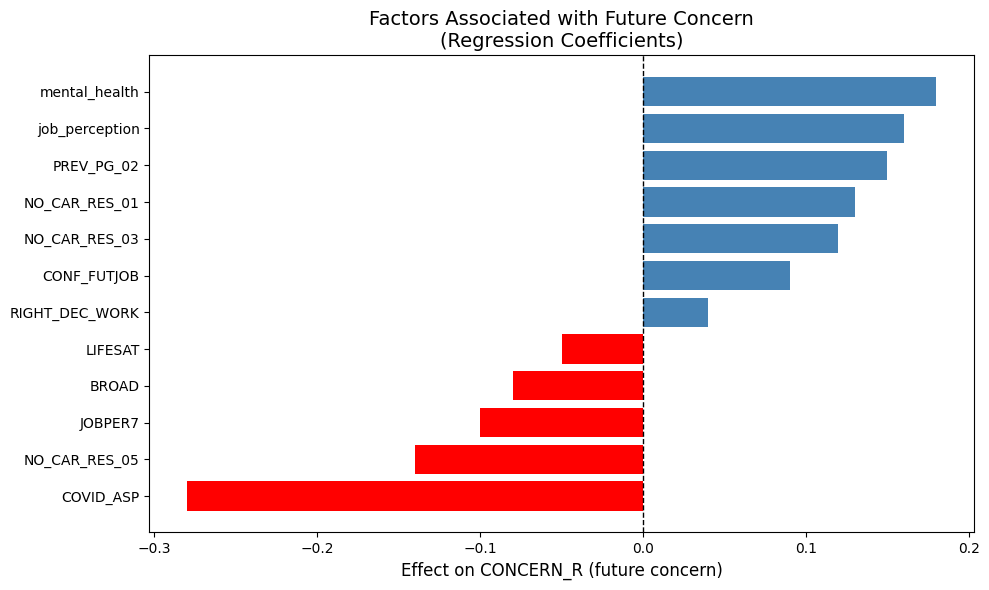

In [34]:
import matplotlib.pyplot as plt
import pandas as pd


coeff_data = pd.DataFrame({
    'Variable': ['COVID_ASP', 'mental_health', 'job_perception', 'PREV_PG_02',
                 'NO_CAR_RES_01', 'NO_CAR_RES_03', 'NO_CAR_RES_05',
                 'CONF_FUTJOB', 'JOBPER7', 'BROAD', 'LIFESAT', 'RIGHT_DEC_WORK'],
    'Coefficient': [-0.28, 0.18, 0.16, 0.15, 0.13, 0.12, -0.14, 0.09, -0.10, -0.08, -0.05, 0.04]
})


coeff_data = coeff_data.sort_values('Coefficient')

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'steelblue' for x in coeff_data['Coefficient']]
plt.barh(coeff_data['Variable'], coeff_data['Coefficient'], color=colors)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Effect on CONCERN_R (future concern)', fontsize=12)
plt.title('Factors Associated with Future Concern\n(Regression Coefficients)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
#Export to aspire3_tableau_data.csv
final_predictors = [
    'COVID_ASP', 'LIFESAT', 'job_perception', 'CONF_FUTJOB', 'JOBPER7',
    'RIGHT_DEC_WORK', 'NO_CAR_RES_05', 'PREV_PG_02', 'BROAD',
    'NO_CAR_RES_01', 'NO_CAR_RES_03', 'mental_health'
]

demographic_cols = ['GENDER', 'parent_uni', 'REGION', 'ETH']

# Ensure all columns exist
existing_demo = [col for col in demographic_cols if col in df_top20.columns]
if 'parent_uni' not in existing_demo:
    print("Warning: parent_uni still missing.")

df_export = df_top20[final_predictors + ['CONCERN_R'] + existing_demo].dropna()
df_export.to_csv('aspires3_tableau_data.csv', index=False)
print(f"✅ Exported with {len(df_export)} rows. Columns: {df_export.columns.tolist()}")

## 11. Summary and Conclusions

### Objective
This project aimed to identify the key factors associated with young people’s anxiety about their future careers using data from the ASPIRES3 longitudinal study (N = 7,635, ages 21‑22 in England).

### Methods
After extensive data cleaning (handling missing codes 998/999, dropping columns with >50% missing), feature engineering (creating `mental_health` and `job_perception` composites), and variable selection (backward elimination), a linear regression model was built and validated. Multicollinearity was assessed using Variance Inflation Factor (VIF), and model generalizability was evaluated with 5‑fold cross‑validation.

### Key Findings
- **Model Fit:** The final model explains **40.2%** of the variance in future concern (adjusted R² = 39.9%), a strong result for survey‑based research.
- **Predictors:** All 12 predictors are statistically significant (p < 0.05) and show no multicollinearity (all VIFs < 1.6).
- **Top Contributors (by coefficient size):**
  - `COVID_ASP` (−0.28) – Students whose aspirations changed due to COVID‑19 report higher concern.
  - `mental_health` (+0.18) – Greater mental distress → higher concern.
  - `job_perception` (+0.16) – More negative job perceptions → higher concern.
  - `PREV_PG_02` (+0.15) – Financial worry about postgraduate study → higher concern.
  - `NO_CAR_RES_01` (+0.13) – Taking a break from study → higher concern.
  - `NO_CAR_RES_03` (+0.12) – Difficulty accessing careers advice → higher concern.
  - `CONF_FUTJOB` (+0.09) – Lower career confidence → higher concern.
  - `JOBPER7` (−0.10) – Agreement that “need more qualifications” → higher concern.
  - `BROAD` (−0.08) – Certain course choices → lower concern (interpretation depends on coding).
  - `LIFESAT` (−0.05) – Higher life satisfaction → lower concern.
  - `RIGHT_DEC_WORK` (+0.04) – Feeling current work decision was wrong → higher concern.
- **Validation:** Cross‑validation yielded a mean R² of 0.389 (±0.03), confirming that the model generalizes well to unseen data.

### Limitations
- **Cross‑sectional design:** All relationships are correlational; causality cannot be inferred.
- **Sample reduction:** The final model used 3,049 of 7,635 respondents due to listwise deletion of missing data; results may not fully generalize to those with incomplete responses.
- **Self‑report bias:** All measures are based on self‑report, which may be influenced by social desirability, recall bias, or current mood.
- **UK‑specific sample:** Findings may not generalize to other countries or educational systems.
- **Composite reliability:** The `job_perception` composite has modest internal consistency (Cronbach's α = 0.55) – a trade‑off made to resolve multicollinearity and maintain model stability.

### Recommendations for EdTech
Based on the findings, edtech platforms can reduce student career anxiety by focusing on the following actionable areas:

| Area | Actionable Strategy |
|------|---------------------|
| **Career confidence** | Provide success stories, skill‑building modules, and clear career pathways. |
| **Job perceptions** | Showcase positive graduate outcomes and offer career exploration tools. |
| **Mental health** | Integrate well‑being resources and stress management features. |
| **Access to careers advice** | Reduce barriers (e.g., make advice easily accessible, proactive outreach). |
| **Financial concerns** | Highlight scholarship options and earning potential of different careers. |

### Next Steps
Future research could explore:
- Longitudinal changes in concern over time.
- Causal impact of interventions (e.g., A/B testing of career guidance tools).
- Qualitative studies to understand the lived experience behind the numbers.
- Application of machine learning methods (e.g., random forests) to improve predictive accuracy.

---

**Notebook prepared by:** Robin  
**Date:** March 2026